In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
import time
from datetime import timedelta

# Chargement des Data
input_signals = np.load("../Data/X_mvdr_400k.npy")  # Shape attendue: (400000, 3)
output_signals = np.load("../Data/Y_mvdr_400k.npy") # Shape attendue: (400000, 32)

# 3. NORMALISATION DES ANGLES (X)
input_x = torch.from_numpy(input_signals).float() / 60.0
output_x = torch.from_numpy(output_signals).float() * 10

print(input_x.shape)
print(output_x.shape)

torch.Size([400000, 3])
torch.Size([400000, 32])


In [8]:
# des couches de taille multiple de 32       #<---------------------------------------------
class MVDR_FFNN(nn.Module):
    def __init__(self):
        super(MVDR_FFNN, self).__init__()
        # On définit uniquement les couches avec paramètres (poids/biais)
        self.layer1 = nn.Linear(3, 512)
        self.layer2 = nn.Linear(512, 1024)
        self.layer3 = nn.Linear(1024, 2048)
        self.layer4 = nn.Linear(2048, 1024)
        self.layer5 = nn.Linear(1024, 32)
        
    def forward(self, x):
        # On utilise F.leaky_relu (la version fonctionnelle)
        # 0.1 est la pente (negative_slope)
        x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer2(x), 0.1)
        x = F.leaky_relu(self.layer3(x), 0.1)
        x = F.leaky_relu(self.layer4(x), 0.1)
        
        # Pas d'activation sur la dernière couche pour la régression
        x = self.layer5(x)        
        return x

class RMSELoss(nn.Module):      #<---------------------------------------------
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_hat, y):
        loss = torch.sqrt(self.mse(y_hat, y) + self.eps)
        return loss

# =================================================================================================================

# =================================================================================================================

# Device cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Model
model = MVDR_FFNN().to(device)
print(f"device:{device}")
print(model)

# 1. Création du Dataset complet
dataset = TensorDataset(input_x, output_x)

# Division 70% Train, 15% Val, 15% Test
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
# 2. Division réelle
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
# 3. Création des DataLoaders
# Train : Shuffle=True (pour l'apprentissage)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, pin_memory=True)
# Validation : Shuffle=False (pour le suivi du scheduler pendant l'entraînement)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
# Test : Shuffle=False (pour l'évaluation finale "propre")
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)#<---------------------------------------------

# Utilisation de la RMSE (Mean Squared Error) pour comparer les poids
criterion = RMSELoss()

# AdamW avec un Learning Rate standard
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)        #<---------------------------------------------

# =================================================================================================================

# =================================================================================================================

# Optionnel : Un scheduler pour réduire le LR si la perte stagne
# (Aide à obtenir des "nuls" plus profonds à la fin de l'entraînement)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Initialisation
train_losses = []
test_losses = []
epochs = 300  #<---------------------------------------------

# Configuration du Scheduler Cosine
# Il va descendre de façon fluide sans les "marches d'escalier"
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

start_time = time.time()  # On lance le chrono global
print(f" Début de l'entraînement à : {time.strftime('%H:%M:%S')}")

for epoch in range(epochs):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train()
    running_train_loss = 0.0
    # On garde tqdm pour la barre de progression par époque
    loop = tqdm(train_loader, desc=f"Époque [{epoch+1}/{epochs}]", leave=False)
    
    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)        
        loss = criterion(outputs, targets)        
        loss.backward()       
        optimizer.step()       
        
        running_train_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.2e}")

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- PHASE DE TEST (VALIDATION) ---
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader: 
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item()
    
    epoch_test_loss = running_test_loss / len(val_loader)
    test_losses.append(epoch_test_loss)
    
    # Mise à jour du scheduler Cosine (automatique à chaque époque)
    scheduler.step()

    # Récupération du LR actuel pour le suivi
    current_lr = optimizer.param_groups[0]['lr']

    # AFFICHAGE (Indenté à l'intérieur de la boucle pour voir l'évolution)
    # On affiche toutes les époques (ou tu peux mettre un if epoch % 10 == 0:)
    if (epoch + 1) % 10 == 0:
        print(f"Époque [{epoch+1}/{epochs}] | Train: {epoch_train_loss:.6f} | Test: {epoch_test_loss:.6f} | LR: {current_lr:.2e}")

# Calcul du temps total de l'entrainement.
end_time = time.time()
total_duration_seconds = end_time - start_time

# Conversion magique en Heures:Minutes:Secondes
total_time = str(timedelta(seconds=int(total_duration_seconds)))

print("-" * 50)
print(f" ENTRAÎNEMENT TERMINÉ")
print(f" TEMPS TOTAL : {total_time} (HH:MM:SS)")
print("-" * 50)
        

device:cuda
MVDR_FFNN(
  (layer1): Linear(in_features=3, out_features=512, bias=True)
  (layer2): Linear(in_features=512, out_features=1024, bias=True)
  (layer3): Linear(in_features=1024, out_features=2048, bias=True)
  (layer4): Linear(in_features=2048, out_features=1024, bias=True)
  (layer5): Linear(in_features=1024, out_features=32, bias=True)
)
 Début de l'entraînement à : 17:31:43


Époque [10/300] | Train: 0.055911 | Test: 0.053523 | LR: 9.97e-04


Époque [20/300] | Train: 0.045112 | Test: 0.047876 | LR: 9.89e-04


Époque [30/300] | Train: 0.037757 | Test: 0.040251 | LR: 9.76e-04


Époque [40/300] | Train: 0.033479 | Test: 0.032333 | LR: 9.57e-04


...

Époque [260/300] | Train: 0.016740 | Test: 0.017231 | LR: 4.33e-05


Époque [270/300] | Train: 0.016638 | Test: 0.017146 | LR: 2.46e-05


Époque [280/300] | Train: 0.016553 | Test: 0.017076 | LR: 1.10e-05


Époque [290/300] | Train: 0.016495 | Test: 0.017039 | LR: 2.84e-06


Époque [300/300] | Train: 0.016470 | Test: 0.017025 | LR: 1.00e-07
--------------------------------------------------
 ENTRAÎNEMENT TERMINÉ
 TEMPS TOTAL : 0:20:27 (HH:MM:SS)
--------------------------------------------------


In [9]:
model.eval()
total_mse = 0.0
test_samples_count = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 0. Inférence
        outputs = model(inputs)

        # 1. Normalisation des prédictions (Norme 1)
        normes_out = torch.norm(outputs, p=2, dim=1, keepdim=True)
        outputs_norm = outputs / (normes_out + 1e-12)
        
        # 2. Normalisation des targets (Norme 1) 
        normes_tg = torch.norm(targets, p=2, dim=1, keepdim=True)
        targets_norm = targets / (normes_tg + 1e-12)
        
        # 3. Calcul de la MSE sur ce batch
        mse_batch = torch.mean((outputs_norm - targets_norm)**2)
        
        # --- CORRECTION : Accumulation ---
        total_mse += mse_batch.item() * inputs.size(0)
        test_samples_count += inputs.size(0)
        
        if len(all_preds) < 1: 
            all_preds.append(outputs_norm.cpu().numpy())
            all_targets.append(targets_norm.cpu().numpy()) # On stocke aussi la version normée ici

# --- CALCUL DES MÉTRIQUES FINALES ---
final_mse = total_mse / test_samples_count
final_rmse = np.sqrt(final_mse) # Le RMSE global est la racine de la MSE moyenne

print("-" * 60)
print(f" RÉSULTATS DU TEST FINAL (MODÈLE STANDARD - FLOAT32)")
print(f" MSE Moyenne (Normalisée)  : {final_mse:.8e}")
print(f" RMSE Globale (Normalisée) : {final_rmse:.8f}")

score_proximite = 100 * (1 - final_rmse)
print(f" Score de fidélité estimé   : {max(0, score_proximite):.2f}%")
print("-" * 30)

------------------------------------------------------------
 RÉSULTATS DU TEST FINAL (MODÈLE STANDARD - FLOAT32)
 MSE Moyenne (Normalisée)  : 4.56401106e-05
 RMSE Globale (Normalisée) : 0.00675575
 Score de fidélité estimé   : 99.32%
------------------------------


 Graphique sauvegardé : ../models_FFNN/MVDR_FFNN20260617_1755_loss_comparison.png
 MODÈLE SAUVEGARDÉ : ../models_FFNN/MVDR_FFNN20260617_1755_model.pth


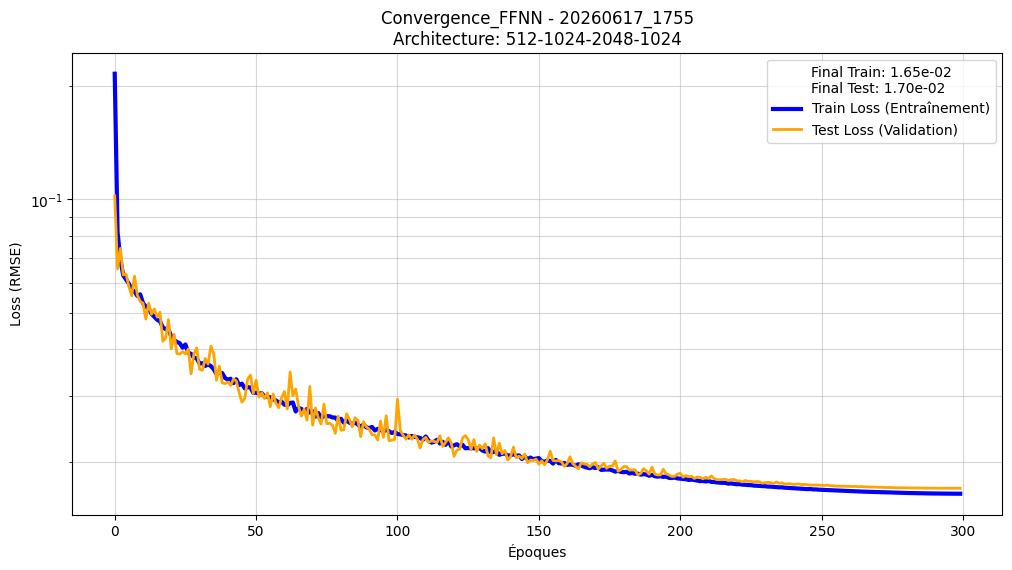

 Graphique sauvegardé : ../models_FFNN/MVDR_FFNN20260617_1755_loss_comparison.png


In [10]:
import os
from datetime import datetime
import matplotlib.pyplot as plt

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
base_filename = f"MVDR_FFNN{timestamp}"

# --- AJOUT POUR SAUVEGARDER LES POIDS DU MODÈLE ---
model_filename = f"{base_filename}_model.pth"
folder_name = "../models_FFNN"
model_path = os.path.join(folder_name, model_filename)
plot_path = os.path.join(folder_name, f"{base_filename}_loss_comparison.png")

# Sauvegarde des poids (state_dict)
torch.save(model.state_dict(), model_path)

print(f" Graphique sauvegardé : {plot_path}")
print(f" MODÈLE SAUVEGARDÉ : {model_path}") # <--- Très important !

# 1. RÉACTIVER L'AFFICHAGE (Annule le mode "Agg")
%matplotlib inline 

# 2. REDÉFINIR LES CHEMINS (Pour éviter le NameError)

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 3. TRACÉ DE LA COURBE
plt.figure(figsize=(12, 6))

plt.plot(train_losses, label='Train Loss (Entraînement)', color='blue', linewidth=3)
plt.plot(test_losses, label='Test Loss (Validation)', color='orange', linewidth=2)

plt.yscale('log') 
plt.title(f"Convergence_FFNN - {timestamp}\nArchitecture: 512-1024-2048-1024", fontsize=12)
plt.xlabel("Époques")
plt.ylabel("Loss (RMSE)")
plt.grid(True, which="both", alpha=0.5)

# Légende avec les scores finaux
last_train = train_losses[-1]
last_test = test_losses[-1]
plt.legend(title=f"Final Train: {last_train:.2e}\nFinal Test: {last_test:.2e}", loc='upper right')

# 4. SAUVEGARDE ET AFFICHAGE
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show() # Maintenant ça va s'afficher car on a mis %matplotlib inline

print(f" Graphique sauvegardé : {plot_path}")